   BRAIN TUMOR DECTECTION                                          

Problem statement


Brain tumors are one of the most serious medical conditions affecting the human brain. Early and accurate detection of brain tumors is very important for effective treatment and improving patient survival rates. Traditionally, brain tumor diagnosis is performed by medical experts through the analysis of Magnetic Resonance Imaging (MRI) scans. However, manual examination of MRI images can be time-consuming, complex, and sometimes prone to human error, especially when a large number of images must be analyzed.

With the rapid growth of Artificial Intelligence and Deep Learning, automated systems can assist doctors in detecting tumors more quickly and accurately. However, developing an efficient model that can correctly classify different types of brain tumors remains a challenge.

Therefore, the main problem addressed in this project is to develop an automated brain tumor detection system using deep learning techniques that can analyze MRI images and accurately classify them into four categories: Glioma, Meningioma, Pituitary tumor, and No Tumor. The goal is to improve diagnostic efficiency and support medical professionals by providing a reliable computer-aided detection system.


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [3]:
DATASET_PATH = r"C:\Users\MICRO\Desktop\brain tumour detection amr\data image\data image"

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=20, 
    width_shift_range=0.2, 
    height_shift_range=0.2, 
    shear_range=0.2, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    validation_split=0.1 )
train_generator =train_datagen.flow_from_directory(
     DATASET_PATH + "\\Training",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH + "\\Training",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation')

Found 5143 images belonging to 4 classes.
Found 569 images belonging to 4 classes.


In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(512,(3,3),activation="relu"),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

c:\Users\MICRO\Desktop\brain tumour detection amr\data image\brainenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
model.fit(train_generator, validation_data=val_generator, epochs=30)

Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 286s 2s/step - accuracy: 0.5444 - loss: 1.0211 - val_accuracy: 0.6573 - val_loss: 0.9130
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.6825 - loss: 0.7787 - val_accuracy: 0.6467 - val_loss: 0.8593
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.7406 - loss: 0.6669 - val_accuracy: 0.7012 - val_loss: 0.7550
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 300s 2s/step - accuracy: 0.7575 - loss: 0.6207 - val_accuracy: 0.7153 - val_loss: 0.6789
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.7908 - loss: 0.5383 - val_accuracy: 0.7399 - val_loss: 0.6303
Epoch 6/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - accuracy: 0.8056 - loss: 0.5065 - val_accuracy: 0.7100 - val_loss: 0.7765
Epoch 7/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.8378 - loss: 0.4202 - val_accuracy: 0.7996 - val_loss: 0.5520
Epoch 8/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.8301 - loss: 0.4261 - val_accu

In [10]:

img_path = r"C:\Users\MICRO\Desktop\brain tumour detection amr\data image\data image\no_tumer.jpg"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step

Predicted Class: No Tumor
Confidence: 100.00%


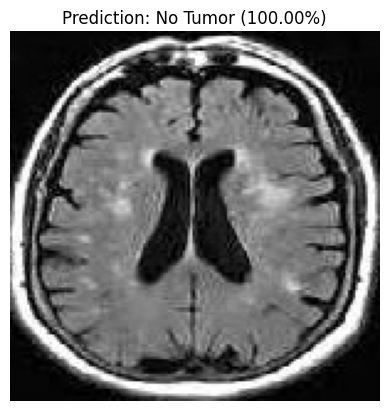

In [11]:
class_labels = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]
img = load_img(img_path, target_size=(150, 150))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0
prediction = model.predict(img_array)
predicted_index = np.argmax(prediction, axis=1)[0]
predicted_label = class_labels[predicted_index]
confidence = np.max(prediction) * 100

print(f"\nPredicted Class: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")


plt.imshow(img)
plt.title(f"Prediction: {predicted_label} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

conclusion

This project developed a brain tumor detection system using deep learning to classify MRI brain images into four categories: Glioma, Meningioma, Pituitary tumor, and No Tumor. The dataset was preprocessed and used to train a classification model capable of identifying tumor types from medical images.

The trained model achieved an accuracy of 94%, indicating that it performs well in distinguishing between different tumor categories and normal brain images. The results show that deep learning techniques are effective for analyzing medical imaging data and extracting meaningful patterns for disease detection.

Overall, the proposed system demonstrates the potential of Artificial Intelligence in assisting medical diagnosis by providing a fast and reliable method for brain tumor classification. With further improvements such as larger datasets and advanced models, the system can become an even more effective tool to support healthcare professionals in early diagnosis and decision-making.